💡 **Environment:** `clamp-analyses`

# Description

**Per-tissue performance summary + tissue-cluster paired bootstrap** — an alternative to the
"max across 49 tissues" aggregation. Consumes `per_tissue_metrics.csv` and
`max_aggregate_reference.csv` (from `00_per_tissue_metrics.ipynb`).

The pipeline collapses each pair's 49 tissue scores with a **max**. Here we instead score each tissue
independently and **aggregate the per-tissue metrics**, then ask the decisive question: **does the
cross-method ordering survive removing the max?**
- If the per-tissue ordering (e.g. ARCHS4 ≥ gene) matches the max-aggregate ordering → the ordering
  is present in the average single tissue and is **not an artifact of the max**.
- If an edge appears **only** under the max → it lives in the per-pair tissue-selection step, which
  could be real tissue-specificity *or* a max-selection artifact; separating those would require a
  dedicated tissue-selection validation (recording which tissue wins per correct prediction).

**Why a *tissue*-level bootstrap.** The `../14_signif_test` bootstrap resamples *pairs*. The estimand here is "per-tissue metric, then aggregate across tissues," so the
cluster unit is the **tissue**: we resample the 49 tissues with replacement and recompute each
method's mean-per-tissue metric on the *same* resampled tissue set (paired across methods; differences
by subtraction), `seed=42`, `N_BOOT=10000`. Per-tissue metrics are precomputed (NB00), so the
bootstrap is pure array indexing.

> **Caveat (stated again below):** the 49 tissues are **not independent** — they share the
> identical 685 pairs, share genes/LVs, and GTEx tissues are mutually correlated. So this is not a
> clean independent-cluster bootstrap and its CIs may be **optimistic**. Read results in the repo's
> established "directional / consistent, significance interpreted cautiously" framing.

**AUPRC headline = `auprc_log2_enrich` = log2(AUPRC / base_rate)** (the base rate is the constant
685-pair prevalence ≈ 0.775, identical across tissues). Helpers `boot_ci` / `boot_pvalue_two_sided` /
`bh_correct` are **copied verbatim** from `../14_signif_test/01_paired_bootstrap_test.ipynb`.

# Modules loading

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import itertools
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

from pyprojroot import here

# Settings

In [3]:
SEED = 42
N_BOOT = 10000

# Same fixed order / sign convention as ../14_signif_test: for a comparison (A, B)
# in METHOD_ORDER, diff = B - A. gene_based first -> gene-vs-module rows read
# 'module - gene' (> 0 means the module model beats the single-gene baseline).
METHOD_ORDER = [
    'gene_based',
    'module_based_archs4',
    'module_based_gtex',
    'module_based_recount2',
]
COMPARISONS = list(itertools.combinations(METHOD_ORDER, 2))  # 6 pairwise

# Metric column in per_tissue_metrics.csv -> display name.
METRICS = {
    'AUROC': 'auroc',
    'AUPRC_log2_enrich': 'auprc_log2_enrich',
}

METHOD_LABEL = {
    'gene_based': 'gene',
    'module_based_archs4': 'ARCHS4',
    'module_based_gtex': 'GTEx',
    'module_based_recount2': 'recount2',
}
METHOD_COLOR = {
    'gene_based': '#444444',
    'module_based_archs4': '#1f77b4',
    'module_based_gtex': '#2ca02c',
    'module_based_recount2': '#d62728',
}

INPUT_DIR = here(
    'output/03_model_biology/00_archs4/02_drug_disease_associations/15_tissue_agg_test')
OUTPUT_DIR = INPUT_DIR
FIG_DIR = OUTPUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
display(OUTPUT_DIR)

PosixPath('/home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/02_drug_disease_associations/15_tissue_agg_test')

# Load per-tissue metrics + max-aggregate reference

In [4]:
per_tissue = pd.read_csv(INPUT_DIR / 'per_tissue_metrics.csv')
per_tissue['method'] = pd.Categorical(
    per_tissue['method'], categories=METHOD_ORDER, ordered=True)
per_tissue = per_tissue.sort_values(['method', 'tissue']).reset_index(drop=True)
display(per_tissue.shape)
display(per_tissue.head())

N_TISSUES = per_tissue['tissue'].nunique()
assert per_tissue.shape[0] == len(METHOD_ORDER) * N_TISSUES
assert not per_tissue[['auroc', 'auprc_log2_enrich']].isna().any().any()
display(f'{N_TISSUES} tissues x {len(METHOD_ORDER)} methods; all per-tissue metrics defined')

max_ref = pd.read_csv(INPUT_DIR / 'max_aggregate_reference.csv').set_index('method').reindex(METHOD_ORDER)
display(max_ref.round(4))

(192, 9)

,method,tissue,n_pos,n_neg,n_total,base_rate,auroc,auprc,auprc_log2_enrich
0,gene_based,Adipose_Subcutaneous,531,154,685,0.775182,0.523045,0.810025,0.063430
1,gene_based,Adipose_Visceral_Omentum,531,154,685,0.775182,0.530065,0.808614,0.060914
2,gene_based,Adrenal_Gland,531,154,685,0.775182,0.492657,0.807052,0.058125
3,gene_based,Artery_Aorta,531,154,685,0.775182,0.534626,0.819678,0.080521
4,gene_based,Artery_Coronary,531,154,685,0.775182,0.555403,0.823885,0.087907


'48 tissues x 4 methods; all per-tissue metrics defined'

,auroc,auprc,auprc_log2_enrich
method,,,
gene_based,0.5828,0.8446,0.1237
module_based_archs4,0.6240,0.8490,0.1312
module_based_gtex,0.5984,0.8377,0.1120
module_based_recount2,0.6118,0.8455,0.1253


# Per-tissue metric matrices (tissues × methods)

Pivot to a `tissue × method` matrix for each metric. All entries are finite (every tissue scores the
identical 685-pair universe), so the cluster bootstrap needs **no skip**.

In [5]:
def metric_matrix(metric_col):
    mat = per_tissue.pivot_table(index='tissue', columns='method', values=metric_col, observed=True)
    mat = mat[METHOD_ORDER]
    assert mat.notna().all().all(), f'{metric_col} has NaN'
    assert mat.shape[0] == N_TISSUES
    return mat

matrices = {mname: metric_matrix(mcol) for mname, mcol in METRICS.items()}
for mname in METRICS:
    display(f'{mname}: {matrices[mname].shape[0]} tissues × {matrices[mname].shape[1]} methods')

'AUROC: 48 tissues × 4 methods'

'AUPRC_log2_enrich: 48 tissues × 4 methods'

# Distribution summary per method + aggregate vs status quo

Per method: macro-mean (mean across the 49 tissues), median, IQR of the per-tissue AUROC and the
log2-AUPRC-enrichment, shown **beside** the max-aggregate (status-quo pooled) value.

These are **different estimands** — the per-tissue aggregate is the mean single-tissue discrimination
(no per-pair tissue selection); the max-aggregate is the discrimination of the best-tissue-selected
score. The contrast (`max_aggregate − mean_per_tissue`) **sizes how much per-pair best-tissue
selection adds**; it is not one number computed two ways.

In [6]:
summary_rows = []
for m in METHOD_ORDER:
    a = matrices['AUROC'][m].values
    e = matrices['AUPRC_log2_enrich'][m].values
    summary_rows.append({
        'method': m,
        'n_tissues': N_TISSUES,
        'macro_mean_auroc': a.mean(),
        'median_auroc': float(np.median(a)),
        'q25_auroc': float(np.percentile(a, 25)),
        'q75_auroc': float(np.percentile(a, 75)),
        'max_aggregate_auroc': float(max_ref.loc[m, 'auroc']),
        'selection_gain_auroc': float(max_ref.loc[m, 'auroc'] - a.mean()),
        'macro_mean_log2enrich': e.mean(),
        'median_log2enrich': float(np.median(e)),
        'max_aggregate_log2enrich': float(max_ref.loc[m, 'auprc_log2_enrich']),
        'selection_gain_log2enrich': float(max_ref.loc[m, 'auprc_log2_enrich'] - e.mean()),
    })
summary = pd.DataFrame(summary_rows)
summary['method'] = pd.Categorical(summary['method'], categories=METHOD_ORDER, ordered=True)
summary = summary.sort_values('method').reset_index(drop=True)

out_summary = OUTPUT_DIR / 'per_tissue_macro_summary.csv'
summary.to_csv(out_summary, index=False)
display(out_summary)
display(summary.round(4))

PosixPath('/home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/02_drug_disease_associations/15_tissue_agg_test/per_tissue_macro_summary.csv')

,method,n_tissues,macro_mean_auroc,median_auroc,q25_auroc,q75_auroc,max_aggregate_auroc,selection_gain_auroc,macro_mean_log2enrich,median_log2enrich,max_aggregate_log2enrich,selection_gain_log2enrich
0,gene_based,48,0.5417,0.5417,0.5280,0.5570,0.5828,0.0412,0.0804,0.0820,0.1237,0.0433
1,module_based_archs4,48,0.5548,0.5536,0.5394,0.5741,0.6240,0.0692,0.0885,0.0872,0.1312,0.0427
2,module_based_gtex,48,0.5265,0.5257,0.5055,0.5439,0.5984,0.0719,0.0601,0.0600,0.1120,0.0519
3,module_based_recount2,48,0.5471,0.5424,0.5295,0.5653,0.6118,0.0648,0.0819,0.0847,0.1253,0.0434


# Descriptive per-tissue ordering

For each pairwise comparison, the number of the 49 tissues where method B's per-tissue AUROC exceeds
method A's, plus a Wilcoxon signed-rank test across the 49 paired per-tissue AUROCs. This uses the
per-tissue paired structure directly (complementary to the cluster bootstrap below).

In [7]:
ordering_rows = []
for mname, mcol in METRICS.items():
    mat = matrices[mname]
    for method_a, method_b in COMPARISONS:
        d = mat[method_b].values - mat[method_a].values
        n_b_wins = int((d > 0).sum())
        n_ties = int((d == 0).sum())
        # Wilcoxon signed-rank (two-sided); undefined if all diffs are zero.
        try:
            w_stat, w_p = wilcoxon(d)
        except ValueError:
            w_stat, w_p = np.nan, np.nan
        ordering_rows.append({
            'metric': mname,
            'comparison': f'{method_b} vs {method_a}',
            'method_a': method_a,
            'method_b': method_b,
            'n_tissues': len(d),
            'n_b_wins': n_b_wins,
            'n_ties': n_ties,
            'frac_b_wins': n_b_wins / len(d),
            'mean_diff': float(d.mean()),
            'wilcoxon_p': float(w_p),
        })
ordering = pd.DataFrame(ordering_rows)
out_ordering = OUTPUT_DIR / 'per_tissue_ordering.csv'
ordering.to_csv(out_ordering, index=False)
display(out_ordering)
display(ordering[ordering['metric'] == 'AUROC'].round(4))

PosixPath('/home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/02_drug_disease_associations/15_tissue_agg_test/per_tissue_ordering.csv')

,metric,comparison,method_a,method_b,n_tissues,n_b_wins,n_ties,frac_b_wins,mean_diff,wilcoxon_p
0,AUROC,module_based_archs4 vs gene_based,gene_based,module_based_archs4,48,29,0,0.6042,0.0131,0.0032
1,AUROC,module_based_gtex vs gene_based,gene_based,module_based_gtex,48,14,0,0.2917,-0.0152,0.0021
2,AUROC,module_based_recount2 vs gene_based,gene_based,module_based_recount2,48,25,0,0.5208,0.0054,0.2341
3,AUROC,module_based_gtex vs module_based_archs4,module_based_archs4,module_based_gtex,48,9,0,0.1875,-0.0283,0.0000
4,AUROC,module_based_recount2 vs module_based_archs4,module_based_archs4,module_based_recount2,48,19,0,0.3958,-0.0077,0.0552
5,AUROC,module_based_recount2 vs module_based_gtex,module_based_gtex,module_based_recount2,48,37,0,0.7708,0.0206,0.0001


# Tissue-cluster paired bootstrap

Resample the 49 **tissues** with replacement; recompute every method's mean-per-tissue metric on the
*same* resampled tissue set (paired); the 6 pairwise differences are `macro_b − macro_a`. A single
resample per iteration is shared across both metrics (separate hypothesis families, but a shared
resample keeps within-iteration comparisons aligned), `seed=42`.

In [8]:
def boot_ci(arr, lo=2.5, hi=97.5):
    return np.percentile(arr, lo), np.percentile(arr, hi)


def boot_pvalue_two_sided(diffs):
    """Two-sided bootstrap p-value for H0: diff == 0.

    Uses the (count + 1) / (N + 1) convention (Davison & Hinkley 1997) so the
    p-value is never exactly 0 -- it is floored at 2 / (N + 1).
    """
    n = len(diffs)
    p_le = ((diffs <= 0).sum() + 1) / (n + 1)
    p_ge = ((diffs >= 0).sum() + 1) / (n + 1)
    return min(2.0 * min(p_le, p_ge), 1.0)


def bh_correct(pvals):
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = ranked * m / (np.arange(m) + 1)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    out = np.empty(m)
    out[order] = np.minimum(adj, 1.0)
    return out

In [9]:
np.random.seed(SEED)

mats = {mname: matrices[mname].values for mname in METRICS}   # (n_tissues, n_methods)
observed_macro = {mname: mats[mname].mean(axis=0) for mname in METRICS}
boot_macro = {mname: np.empty((N_BOOT, len(METHOD_ORDER))) for mname in METRICS}

for b in range(N_BOOT):
    idx = np.random.choice(N_TISSUES, N_TISSUES, replace=True)   # same tissue resample, all methods
    for mname in METRICS:
        boot_macro[mname][b] = mats[mname][idx].mean(axis=0)

display('bootstrap done; shapes:')
display({mn: arr.shape for mn, arr in boot_macro.items()})

'bootstrap done; shapes:'

{'AUROC': (10000, 4), 'AUPRC_log2_enrich': (10000, 4)}

# Results: CI + bootstrap p-value on each macro-mean difference

In [10]:
midx = {m: i for i, m in enumerate(METHOD_ORDER)}
rows = []
for mname in METRICS:
    boot = boot_macro[mname]
    obs = observed_macro[mname]
    for method_a, method_b in COMPARISONS:
        ia, ib = midx[method_a], midx[method_b]
        boot_a, boot_b = boot[:, ia], boot[:, ib]
        boot_diff = boot_b - boot_a            # paired: same tissue resample per iteration
        a_lo, a_hi = boot_ci(boot_a)
        b_lo, b_hi = boot_ci(boot_b)
        diff_lo, diff_hi = boot_ci(boot_diff)
        rows.append({
            'metric': mname,
            'comparison': f'{method_b} vs {method_a}',
            'method_a': method_a,
            'method_b': method_b,
            'a_obs': obs[ia], 'a_lo': a_lo, 'a_hi': a_hi,
            'b_obs': obs[ib], 'b_lo': b_lo, 'b_hi': b_hi,
            'diff_obs': obs[ib] - obs[ia],
            'diff_boot_mean': boot_diff.mean(),
            'diff_ci_lo': diff_lo, 'diff_ci_hi': diff_hi,
            'ci_excludes_0': bool(diff_lo > 0 or diff_hi < 0),
            'p_value': boot_pvalue_two_sided(boot_diff),
        })
results = pd.DataFrame(rows)

# BH WITHIN each metric family (the 6 comparisons for one metric); AUROC and
# AUPRC enrichment are distinct families.
results['p_value_bh'] = (
    results.groupby('metric', sort=False)['p_value'].transform(bh_correct))

out_csv = OUTPUT_DIR / 'per_tissue_bootstrap_results.csv'
out_pkl = OUTPUT_DIR / 'per_tissue_bootstrap_results.pkl'
results.to_csv(out_csv, index=False)
results.to_pickle(out_pkl)
display(out_csv)
display(f'{len(results)} rows ({len(METRICS)} metrics × {len(COMPARISONS)} comparisons)')

display(
    results[results['metric'] == 'AUROC']
    .sort_values('p_value_bh')
    [['comparison', 'a_obs', 'b_obs', 'diff_obs',
      'diff_ci_lo', 'diff_ci_hi', 'ci_excludes_0', 'p_value', 'p_value_bh']]
    .reset_index(drop=True).round(4))

PosixPath('/home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/02_drug_disease_associations/15_tissue_agg_test/per_tissue_bootstrap_results.csv')

'12 rows (2 metrics × 6 comparisons)'

,comparison,a_obs,b_obs,diff_obs,diff_ci_lo,diff_ci_hi,ci_excludes_0,p_value,p_value_bh
0,module_based_gtex vs module_based_archs4,0.5548,0.5265,-0.0283,-0.0381,-0.0186,True,0.0002,0.0006
1,module_based_recount2 vs module_based_gtex,0.5265,0.5471,0.0206,0.0110,0.0299,True,0.0002,0.0006
2,module_based_archs4 vs gene_based,0.5417,0.5548,0.0131,0.0057,0.0206,True,0.0008,0.0016
3,module_based_gtex vs gene_based,0.5417,0.5265,-0.0152,-0.0251,-0.0053,True,0.0034,0.0051
4,module_based_recount2 vs module_based_archs4,0.5548,0.5471,-0.0077,-0.0156,0.0006,False,0.0712,0.0854
5,module_based_recount2 vs gene_based,0.5417,0.5471,0.0054,-0.0020,0.0131,False,0.1622,0.1622


# Plots

/tmp/ipykernel_1299704/453858304.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=per_tissue, x='method', y='auroc', order=order, ax=ax,
/tmp/ipykernel_1299704/453858304.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


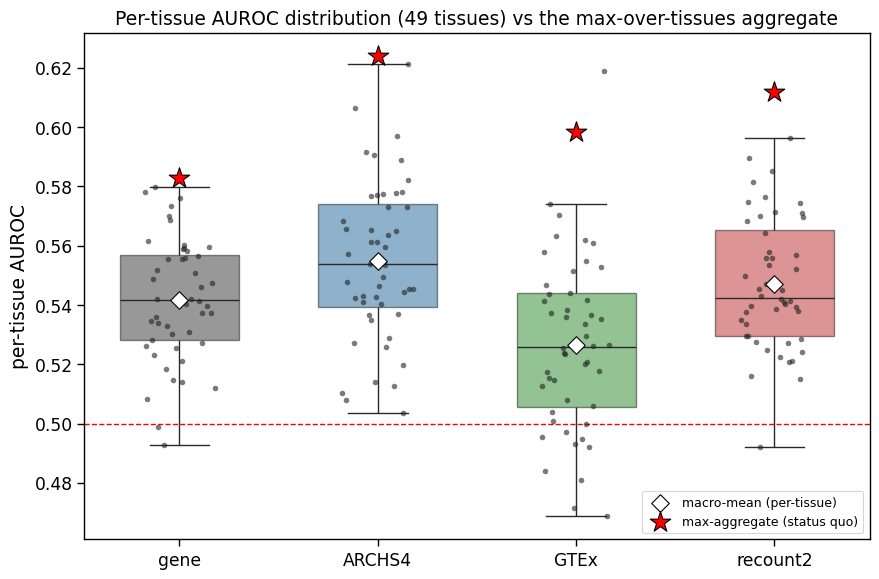

In [11]:
# --- Per-tissue AUROC distribution (box + strip), with the macro-mean (diamond)
# and the status-quo max-aggregate (red star) overlaid per method ---
order = METHOD_ORDER
palette = [METHOD_COLOR[m] for m in order]
labels = [METHOD_LABEL[m] for m in order]

with sns.plotting_context('paper', font_scale=1.4):
    fig, ax = plt.subplots(figsize=(9, 6))
    sns.boxplot(data=per_tissue, x='method', y='auroc', order=order, ax=ax,
                palette=palette, showfliers=False, width=0.6, boxprops=dict(alpha=0.55))
    sns.stripplot(data=per_tissue, x='method', y='auroc', order=order, ax=ax,
                  color='#222222', size=4, jitter=0.18, alpha=0.6)
    macro = per_tissue.groupby('method', observed=True)['auroc'].mean().reindex(order)
    ax.scatter(range(len(order)), macro.values, marker='D', s=80,
               color='white', edgecolor='black', zorder=10, label='macro-mean (per-tissue)')
    ax.scatter(range(len(order)), max_ref['auroc'].values, marker='*', s=240,
               color='red', edgecolor='black', zorder=11, label='max-aggregate (status quo)')
    ax.axhline(0.5, color='red', linestyle='--', linewidth=1)
    ax.set_xticklabels(labels)
    ax.set_xlabel('')
    ax.set_ylabel('per-tissue AUROC')
    ax.set_title('Per-tissue AUROC distribution (49 tissues) vs the max-over-tissues aggregate')
    ax.legend(loc='lower right', fontsize=9)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'per_tissue_auroc_dist.png', dpi=150, bbox_inches='tight',
                facecolor='white')
    plt.show()

/tmp/ipykernel_1299704/1211721858.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=per_tissue, x='method', y='auprc_log2_enrich', order=order, ax=ax,
/tmp/ipykernel_1299704/1211721858.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


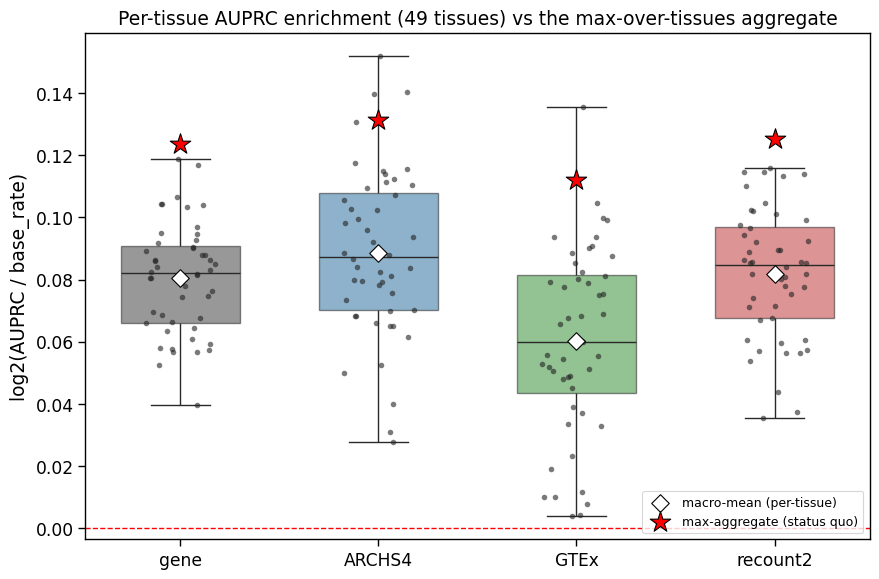

In [12]:
# --- Per-tissue log2 AUPRC enrichment distribution (0 = no better than prior) ---
with sns.plotting_context('paper', font_scale=1.4):
    fig, ax = plt.subplots(figsize=(9, 6))
    sns.boxplot(data=per_tissue, x='method', y='auprc_log2_enrich', order=order, ax=ax,
                palette=palette, showfliers=False, width=0.6, boxprops=dict(alpha=0.55))
    sns.stripplot(data=per_tissue, x='method', y='auprc_log2_enrich', order=order, ax=ax,
                  color='#222222', size=4, jitter=0.18, alpha=0.6)
    macro = per_tissue.groupby('method', observed=True)['auprc_log2_enrich'].mean().reindex(order)
    ax.scatter(range(len(order)), macro.values, marker='D', s=80,
               color='white', edgecolor='black', zorder=10, label='macro-mean (per-tissue)')
    ax.scatter(range(len(order)), max_ref['auprc_log2_enrich'].values, marker='*', s=240,
               color='red', edgecolor='black', zorder=11, label='max-aggregate (status quo)')
    ax.axhline(0.0, color='red', linestyle='--', linewidth=1)
    ax.set_xticklabels(labels)
    ax.set_xlabel('')
    ax.set_ylabel('log2(AUPRC / base_rate)')
    ax.set_title('Per-tissue AUPRC enrichment (49 tissues) vs the max-over-tissues aggregate')
    ax.legend(loc='lower right', fontsize=9)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'per_tissue_auprc_enrich_dist.png', dpi=150, bbox_inches='tight',
                facecolor='white')
    plt.show()

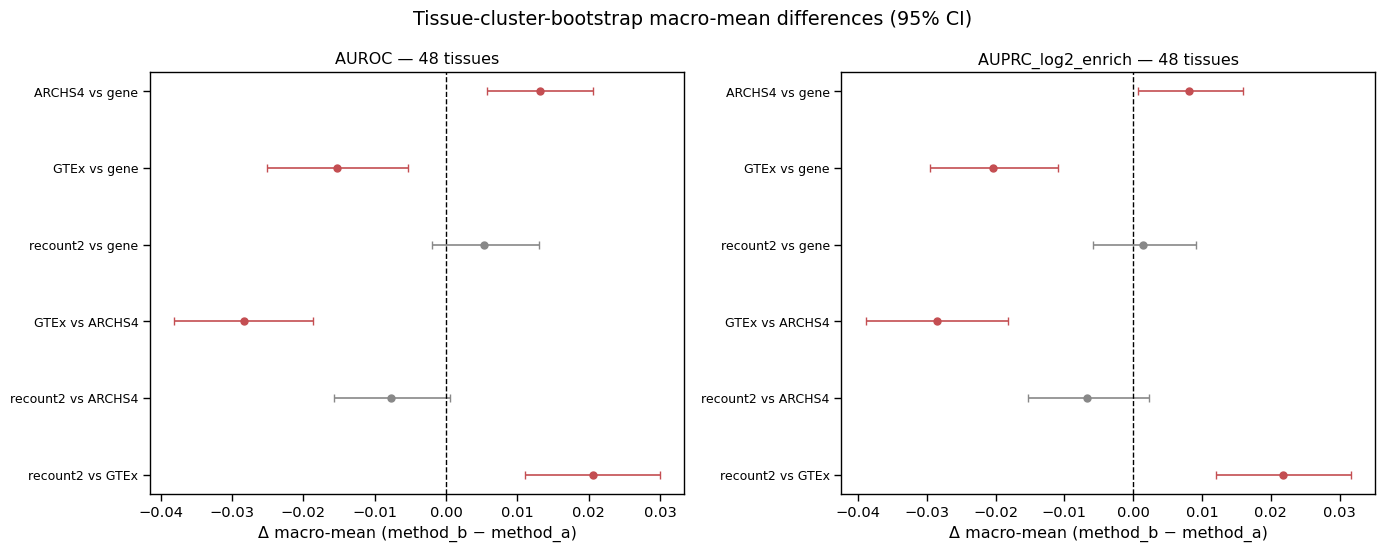

In [13]:
# --- Forest plot of macro-mean differences (one panel per metric) ---
metric_list = list(METRICS)
with sns.plotting_context('paper', font_scale=1.2):
    fig, axes = plt.subplots(
        1, len(metric_list),
        figsize=(7 * len(metric_list), 0.6 * len(COMPARISONS) + 2), squeeze=False)
    for j, mname in enumerate(metric_list):
        ax = axes[0][j]
        sub = results[results['metric'] == mname].reset_index(drop=True)
        ypos = np.arange(len(sub))[::-1]
        for y, (_, r) in zip(ypos, sub.iterrows()):
            color = '#C44E52' if r['ci_excludes_0'] else '#888888'
            ax.errorbar(
                r['diff_obs'], y,
                xerr=[[r['diff_obs'] - r['diff_ci_lo']],
                      [r['diff_ci_hi'] - r['diff_obs']]],
                fmt='o', color=color, ecolor=color, capsize=3, markersize=5)
        ax.axvline(0, color='black', linestyle='--', linewidth=1)
        ax.set_yticks(ypos)
        ax.set_yticklabels(
            [f"{METHOD_LABEL[r['method_b']]} vs {METHOD_LABEL[r['method_a']]}"
             for _, r in sub.iterrows()], fontsize=9)
        ax.set_title(f'{mname} — {N_TISSUES} tissues')
        ax.set_xlabel('Δ macro-mean (method_b − method_a)')
    fig.suptitle('Tissue-cluster-bootstrap macro-mean differences (95% CI)')
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'per_tissue_macro_diff_forest.png', dpi=150, bbox_inches='tight',
                facecolor='white')
    plt.show()

# Write FINDINGS.md

In [14]:
def _fmt_macro(metric_col):
    s = per_tissue.groupby('method', observed=True)[metric_col].mean().reindex(METHOD_ORDER)
    return ', '.join(f'{METHOD_LABEL[m]}={s[m]:.4f}' for m in METHOD_ORDER)


def _fmt_maxagg(col):
    return ', '.join(f'{METHOD_LABEL[m]}={max_ref.loc[m, col]:.4f}' for m in METHOD_ORDER)


def _fmt_diff_rows(metric):
    sub = results[results['metric'] == metric]
    lines = []
    for _, r in sub.iterrows():
        sig = 'SIGNIFICANT' if r['ci_excludes_0'] else 'n.s.'
        lines.append(
            f"- {METHOD_LABEL[r['method_b']]} vs {METHOD_LABEL[r['method_a']]}: "
            f"diff={r['diff_obs']:+.4f} [{r['diff_ci_lo']:+.4f}, {r['diff_ci_hi']:+.4f}], "
            f"p={r['p_value']:.3f} (BH {r['p_value_bh']:.3f}) -> {sig}")
    return '\n'.join(lines)


# Per-tissue aggregate ordering vs max-aggregate ordering (by AUROC).
macro_auroc = per_tissue.groupby('method', observed=True)['auroc'].mean().reindex(METHOD_ORDER)
pt_order = [METHOD_LABEL[m] for m in macro_auroc.sort_values(ascending=False).index]
mx_order = [METHOD_LABEL[m] for m in max_ref['auroc'].sort_values(ascending=False).index]

# ARCHS4-vs-gene rows (the headline LV-vs-baseline contrast).
def _row(metric, a, b):
    return results[(results.metric == metric) & (results.method_a == a) & (results.method_b == b)].iloc[0]
ag_auroc = _row('AUROC', 'gene_based', 'module_based_archs4')

# ARCHS4 beats gene in how many of 49 tissues.
ag_ord = ordering[(ordering.metric == 'AUROC') & (ordering.method_a == 'gene_based')
                  & (ordering.method_b == 'module_based_archs4')].iloc[0]

sig = results[results['p_value_bh'] < 0.05]
if len(sig) == 0:
    sig_summary = ('No pairwise difference is BH-significant in either metric '
                   '(all tissue-cluster-bootstrap CIs cross 0).')
else:
    parts = [
        f"{METHOD_LABEL[r['method_b']]} vs {METHOD_LABEL[r['method_a']]} "
        f"({r['metric']}: diff={r['diff_obs']:+.3f}, BH p={r['p_value_bh']:.3f})"
        for _, r in sig.iterrows()]
    sig_summary = 'BH-significant differences: ' + '; '.join(parts) + '.'

base_rate = float(per_tissue['base_rate'].iloc[0])
n_pos = int(per_tissue['n_pos'].iloc[0])
n_neg = int(per_tissue['n_neg'].iloc[0])

text = f"""# Findings — per-tissue AUROC + AUPRC (max-over-tissues alternative)

The pipeline collapses each (drug, disease) pair's **49 tissue scores with a max** before pooling
into one AUROC. Here we instead compute AUROC/AUPRC **per tissue**
(over the constant {n_pos + n_neg}-pair universe, {n_pos} pos / {n_neg} neg, base_rate {base_rate:.4f})
and **aggregate across tissues** — removing the per-pair tissue-selection step entirely. Tissue-cluster
paired bootstrap N={N_BOOT} (seed {SEED}), resampling the **{N_TISSUES} tissues**. AUPRC headline =
`log2(AUPRC / base_rate)`.

## Aggregate AUROC by method: per-tissue (mean over {N_TISSUES} tissues) vs status-quo max-aggregate
- mean per-tissue:  {_fmt_macro('auroc')}
- max-aggregate:    {_fmt_maxagg('auroc')}
- Ordering (per-tissue, high->low):   {' > '.join(pt_order)}
- Ordering (max-aggregate, high->low): {' > '.join(mx_order)}

## Aggregate log2 AUPRC enrichment by method
- mean per-tissue:  {_fmt_macro('auprc_log2_enrich')}
- max-aggregate:    {_fmt_maxagg('auprc_log2_enrich')}

## Pairwise macro-mean AUROC differences (tissue-cluster bootstrap, diff = b - a)
{_fmt_diff_rows('AUROC')}

## Pairwise macro-mean log2-AUPRC-enrichment differences
{_fmt_diff_rows('AUPRC_log2_enrich')}

## Descriptive per-tissue ordering (AUROC)
- ARCHS4 > gene in {ag_ord['n_b_wins']}/{int(ag_ord['n_tissues'])} tissues
  (mean per-tissue diff {ag_ord['mean_diff']:+.4f}, Wilcoxon p {ag_ord['wilcoxon_p']:.3f}).

## Read
- **Does the cross-method ordering survive removing the max?** Per-tissue ordering
  `{' > '.join(pt_order)}` vs max-aggregate `{' > '.join(mx_order)}`. If these agree, the ordering is
  present in the average single tissue and is **not an artifact of the max**; if ARCHS4's edge over
  gene is present under max but absent per-tissue, the edge lives in the per-pair tissue-selection
  step (real tissue-specificity *or* a max-selection artifact, which this analysis does not separate).
- **ARCHS4 vs gene (per-tissue aggregate):** diff {ag_auroc['diff_obs']:+.4f}
  [{ag_auroc['diff_ci_lo']:+.4f}, {ag_auroc['diff_ci_hi']:+.4f}], BH p {ag_auroc['p_value_bh']:.3f}
  -> {'SIGNIFICANT' if ag_auroc['ci_excludes_0'] else 'n.s.'}.
- **Significance:** {sig_summary}
- **Selection gain.** `max_aggregate - mean_per_tissue` (per method, in `per_tissue_macro_summary.csv`)
  quantifies how much per-pair best-tissue selection adds over the average single tissue.

## Caveats
- **The {N_TISSUES} tissues are NOT independent** — they share the identical {n_pos + n_neg} pairs,
  share genes/LVs, and GTEx tissues are mutually correlated. The tissue-cluster bootstrap treats them
  as exchangeable, so its CIs may be **optimistic** (anti-conservative). Treat significance cautiously,
  in the repo's "directional / consistent" framing.
- **Different estimands.** Mean per-tissue AUROC (no selection) and the max-aggregate AUROC
  (best-tissue selection) answer different questions; the contrast sizes selection, it is not a
  like-for-like re-computation of one number.
- **n={N_TISSUES} clusters**, methods are correlated (shared inputs, not independent replications).
- **Not covered here:** the tissue-selection biological validation (which tissue wins per correct
  prediction) and the second max (UKB-trait->DOID collapse in `map_traits_to_doid`).
"""

out_md = OUTPUT_DIR / 'FINDINGS.md'
out_md.write_text(text)
display(out_md)
print(text)

PosixPath('/home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/02_drug_disease_associations/15_tissue_agg_test/FINDINGS.md')

# Findings — per-tissue AUROC + AUPRC (max-over-tissues alternative)

The pipeline collapses each (drug, disease) pair's **49 tissue scores with a max** before pooling
into one AUROC. Here we instead compute AUROC/AUPRC **per tissue**
(over the constant 685-pair universe, 531 pos / 154 neg, base_rate 0.7752)
and **aggregate across tissues** — removing the per-pair tissue-selection step entirely. Tissue-cluster
paired bootstrap N=10000 (seed 42), resampling the **48 tissues**. AUPRC headline =
`log2(AUPRC / base_rate)`.

## Aggregate AUROC by method: per-tissue (mean over 48 tissues) vs status-quo max-aggregate
- mean per-tissue:  gene=0.5417, ARCHS4=0.5548, GTEx=0.5265, recount2=0.5471
- max-aggregate:    gene=0.5828, ARCHS4=0.6240, GTEx=0.5984, recount2=0.6118
- Ordering (per-tissue, high->low):   ARCHS4 > recount2 > gene > GTEx
- Ordering (max-aggregate, high->low): ARCHS4 > recount2 > GTEx > gene

## Aggregate log2 AUPRC enrichment by method
- mean per-tissue:  gene=0.0804, ARCHS4=0